In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import yaml
import pandas as pd

:)

In [2]:
# Conversion yaml a dataframe y despues a array
with open("3HWC.yaml", "r", encoding="utf-8") as file:
    data = list(yaml.safe_load(file))
df = pd.DataFrame(data)

# Extraccion de columnas

RA = np.array(df["RA"]).tolist()
Dec = np.array(df["Dec"]).tolist()
TS = np.array(df["TS"]).tolist()
TS_max = np.max(TS)
TS_min = np.min(TS)
TS_scale = TS / TS_max
TS_scale = TS_scale * 300

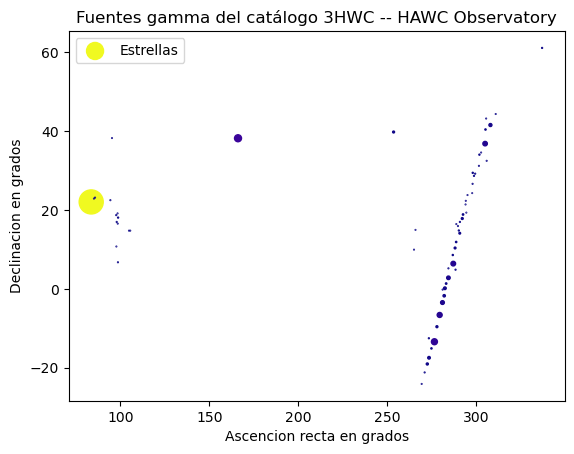

In [3]:
# Grafica de estrellas detectadas a escala
fig, ax = plt.subplots()
ax.scatter(RA, Dec, label="Estrellas", c=TS, s=TS_scale, cmap="plasma")
ax.set_xlabel("Ascencion recta en grados")
ax.set_ylabel("Declinacion en grados")
ax.set_title("Fuentes gamma del catálogo 3HWC -- HAWC Observatory")
ax.legend()
plt.savefig("grafica_estrellas.png", dpi = 300, bbox_inches="tight")
plt.show()

In [4]:
# Histograma de TS escala logaritmica
bins = np.logspace(np.log10(TS_min), np.log10(TS_max), 65)  # Bins para TS
conteo, bordes = np.histogram(TS, bins=bins)

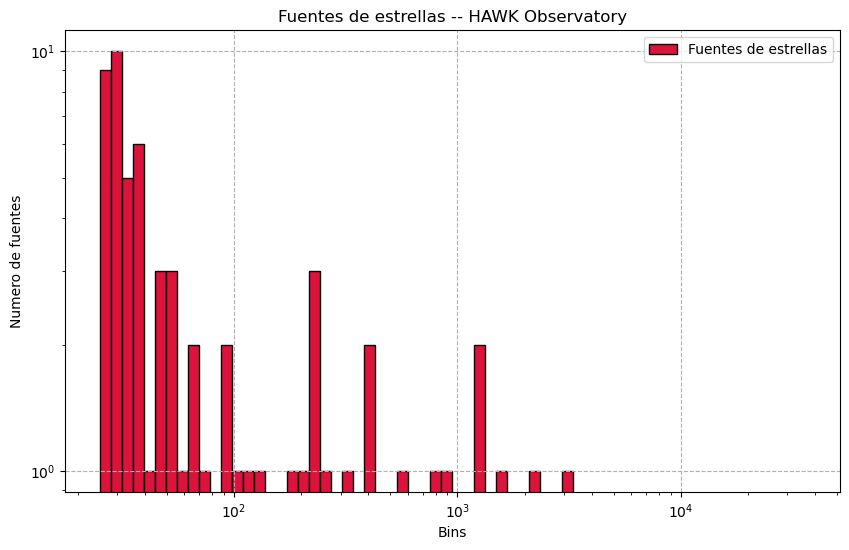

In [5]:
# Graficacion de histograma
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(bordes[:-1], # Ajuste de dimensiones
       conteo,      # Altura de cada barra
       width=np.diff(bordes),  # Anchura real de cada barra
       align="edge",
       color="crimson",
       edgecolor="black",
       label=("Fuentes de estrellas"))
           
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Bins")
ax.set_ylabel("Numero de fuentes")
ax.grid(True, linestyle="--")
ax.legend()
ax.set_title("Fuentes de estrellas -- HAWK Observatory")
plt.savefig("histograma_TS.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# Analisis estadistico de TS
print("El bin que tiene mas elementos es el numero", np.argmax(conteo), "con", conteo[np.argmax(conteo)], "elementos")
print("La fuente mas significativa es la numero", np.argmax(TS), "con TS =",TS_max)
print("TS promedio:", np.mean(TS))
print("Numero de fuentes:", len(TS))

El bin que tiene mas elementos es el numero 1 con 10 elementos
La fuente mas significativa es la numero 0 con TS = 35736.499681
TS promedio: 797.766204258183
Numero de fuentes: 65
